In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
df = pd.read_csv("/Users/fesavaskurt/Python&ML/Kodlarım/Python/datasets/ML Datasets/13-car_evaluation.csv")

In [36]:
df.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [37]:
df = df.rename(columns={
    "vhigh": "buying",
    "vhigh.1": "maint",
    "2": "doors",
    "2.1": "persons",
    "small": "lug_boot",
    "low": "safety",
    "unacc": "decision"
                        })

In [38]:
df

,buying,maint,doors,persons,lug_boot,safety,decision
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [39]:
df.shape

(1727, 7)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   object
 3   persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   decision  1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [41]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
decision    0
dtype: int64

In [42]:
df["decision"].value_counts()

decision
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [63]:
df["persons"].unique()

array(['2', '4', 'more'], dtype=object)

In [43]:
df["buying"].unique()

array(['vhigh', 'high', 'med', 'low'], dtype=object)

In [44]:
df["maint"].unique()

array(['vhigh', 'high', 'med', 'low'], dtype=object)

In [45]:
df["doors"].unique()

array(['2', '3', '4', '5more'], dtype=object)

In [78]:
df["lug_boot"].unique()

array(['small', 'med', 'big'], dtype=object)

In [47]:
df["safety"].unique()

array(['med', 'high', 'low'], dtype=object)

In [48]:
df["decision"].unique()

array(['unacc', 'acc', 'vgood', 'good'], dtype=object)

In [56]:
df["doors"] = df["doors"].replace('5more', 5)

In [57]:
df["doors"].unique()

array(['2', '3', '4', 5], dtype=object)

In [61]:
df["doors"] = df["doors"].astype(int)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   int64 
 3   persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   decision  1727 non-null   object
dtypes: int64(1), object(6)
memory usage: 94.6+ KB


In [64]:
df["persons"] = df["persons"].replace('more', 5)

In [65]:
df["persons"] = df["persons"].astype(int)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   int64 
 3   persons   1727 non-null   int64 
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   decision  1727 non-null   object
dtypes: int64(2), object(5)
memory usage: 94.6+ KB


In [67]:
from sklearn.preprocessing import OrdinalEncoder

In [73]:
encoder = OrdinalEncoder(categories=[['vhigh', 'high', 'med', 'low']]) 
df['Buying_Encoded'] = encoder.fit_transform(df[['buying']]) 
df['Maint_Encoded'] = encoder.fit_transform(df[['maint']]) 

In [74]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,decision,buying_maint_Encoded,Buying_Encoded,Maint_Encoded
0,vhigh,vhigh,2,2,small,med,unacc,0.0,0.0,0.0
1,vhigh,vhigh,2,2,small,high,unacc,0.0,0.0,0.0
2,vhigh,vhigh,2,2,med,low,unacc,0.0,0.0,0.0
3,vhigh,vhigh,2,2,med,med,unacc,0.0,0.0,0.0
4,vhigh,vhigh,2,2,med,high,unacc,0.0,0.0,0.0


In [75]:
df['Maint_Encoded'].unique()

array([0., 1., 2., 3.])

In [81]:
encoder_lug = OrdinalEncoder()
df["lug_boot_encoded"] = encoder_lug.fit_transform(df[["lug_boot"]])

In [82]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,decision,buying_maint_Encoded,Buying_Encoded,Maint_Encoded,lug_boot_encoded
0,vhigh,vhigh,2,2,small,med,unacc,0.0,0.0,0.0,2.0
1,vhigh,vhigh,2,2,small,high,unacc,0.0,0.0,0.0,2.0
2,vhigh,vhigh,2,2,med,low,unacc,0.0,0.0,0.0,1.0
3,vhigh,vhigh,2,2,med,med,unacc,0.0,0.0,0.0,1.0
4,vhigh,vhigh,2,2,med,high,unacc,0.0,0.0,0.0,1.0


In [ ]:
encoder_safety = OrdinalEncoder()
df["safety_encoded"] = encoder_lug.fit_transform(df[["safety"]])

KeyError: "None of [Index(['safety'], dtype='object')] are in the [columns]"

In [ ]:
encoder_decision= OrdinalEncoder()
df["decision_encoded"] = encoder_decision.fit_transform(df[["decision"]])

In [85]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,decision,buying_maint_Encoded,Buying_Encoded,Maint_Encoded,lug_boot_encoded,safety_encoded,decision_encoded
0,vhigh,vhigh,2,2,small,med,unacc,0.0,0.0,0.0,2.0,2.0,2.0
1,vhigh,vhigh,2,2,small,high,unacc,0.0,0.0,0.0,2.0,0.0,2.0
2,vhigh,vhigh,2,2,med,low,unacc,0.0,0.0,0.0,1.0,1.0,2.0
3,vhigh,vhigh,2,2,med,med,unacc,0.0,0.0,0.0,1.0,2.0,2.0
4,vhigh,vhigh,2,2,med,high,unacc,0.0,0.0,0.0,1.0,0.0,2.0


In [104]:
df = df.drop(columns=["maint", "decision", "safety", "lug_boot", "buying"])

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   doors                 1727 non-null   int64  
 1   persons               1727 non-null   int64  
 2   buying_maint_Encoded  1727 non-null   float64
 3   Buying_Encoded        1727 non-null   float64
 4   Maint_Encoded         1727 non-null   float64
 5   lug_boot_encoded      1727 non-null   float64
 6   safety_encoded        1727 non-null   float64
 7   decision_encoded      1727 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 108.1 KB


In [106]:
df.isnull().sum()

doors                   0
persons                 0
buying_maint_Encoded    0
Buying_Encoded          0
Maint_Encoded           0
lug_boot_encoded        0
safety_encoded          0
decision_encoded        0
dtype: int64

In [107]:
df.describe()

,doors,persons,buying_maint_Encoded,Buying_Encoded,Maint_Encoded,lug_boot_encoded,safety_encoded,decision_encoded
count,1727.000000,1727.000000,1727.000000,1727.000000,1727.000000,1727.000000,1727.00000,1727.000000
mean,3.500869,3.667632,1.500869,1.500869,1.500869,0.999421,1.00000,1.552982
std,1.118098,1.247296,1.118098,1.118098,1.118098,0.816615,0.81697,0.876136
min,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,3.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.00000,1.000000
50%,4.000000,4.000000,2.000000,2.000000,2.000000,1.000000,1.00000,2.000000
75%,4.500000,5.000000,2.500000,2.500000,2.500000,2.000000,2.00000,2.000000
max,5.000000,5.000000,3.000000,3.000000,3.000000,2.000000,2.00000,3.000000


<Axes: xlabel='persons', ylabel='buying_maint_Encoded'>

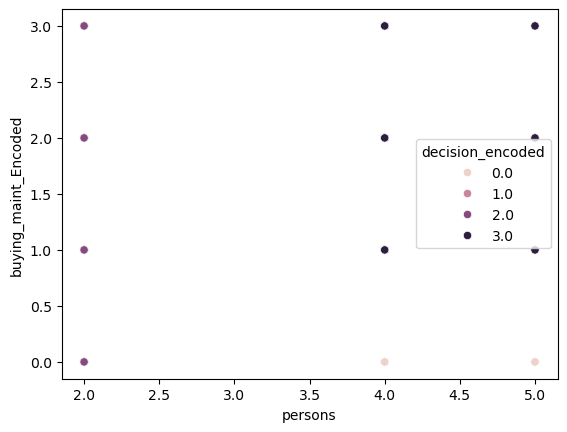

In [113]:
sns.scatterplot(x = df["persons"], y = df["buying_maint_Encoded"], hue=df["decision_encoded"])

In [114]:
from sklearn.model_selection import train_test_split

In [117]:
X = df.drop("decision_encoded", axis=1)
y = df["decision_encoded"]

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state= 42, test_size= 0.2
)

In [119]:
from sklearn.tree import DecisionTreeClassifier

In [120]:
model = DecisionTreeClassifier()

In [121]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [123]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("score: ", accuracy_score(y_pred, y_test))
print("matrix: ", confusion_matrix(y_pred, y_test))
print("classification: ", classification_report(y_pred, y_test))

score:  0.9566473988439307
matrix:  [[ 69   2   1   1]
 [  2  12   0   2]
 [  5   0 236   0]
 [  1   1   0  14]]
classification:                precision    recall  f1-score   support

         0.0       0.90      0.95      0.92        73
         1.0       0.80      0.75      0.77        16
         2.0       1.00      0.98      0.99       241
         3.0       0.82      0.88      0.85        16

    accuracy                           0.96       346
   macro avg       0.88      0.89      0.88       346
weighted avg       0.96      0.96      0.96       346



In [125]:
model.score(X_train, y_train)

1.0

In [126]:
model.score(X_test, y_test)

0.9566473988439307

In [127]:
model_3_depth = DecisionTreeClassifier(max_depth=3)
model_3_depth.fit(X_train, y_train)
y_pred3 = model.predict(X_test)
print("score: ", accuracy_score(y_pred3, y_test))
print("matrix: ", confusion_matrix(y_pred3, y_test))
print("classification: ", classification_report(y_pred3, y_test))

score:  0.9566473988439307
matrix:  [[ 69   2   1   1]
 [  2  12   0   2]
 [  5   0 236   0]
 [  1   1   0  14]]
classification:                precision    recall  f1-score   support

         0.0       0.90      0.95      0.92        73
         1.0       0.80      0.75      0.77        16
         2.0       1.00      0.98      0.99       241
         3.0       0.82      0.88      0.85        16

    accuracy                           0.96       346
   macro avg       0.88      0.89      0.88       346
weighted avg       0.96      0.96      0.96       346



In [128]:
model_5_depth = DecisionTreeClassifier(max_depth=5)
model_5_depth.fit(X_train, y_train)
y_pred5 = model.predict(X_test)
print("score: ", accuracy_score(y_pred5, y_test))
print("matrix: ", confusion_matrix(y_pred5, y_test))
print("classification: ", classification_report(y_pred5, y_test))

score:  0.9566473988439307
matrix:  [[ 69   2   1   1]
 [  2  12   0   2]
 [  5   0 236   0]
 [  1   1   0  14]]
classification:                precision    recall  f1-score   support

         0.0       0.90      0.95      0.92        73
         1.0       0.80      0.75      0.77        16
         2.0       1.00      0.98      0.99       241
         3.0       0.82      0.88      0.85        16

    accuracy                           0.96       346
   macro avg       0.88      0.89      0.88       346
weighted avg       0.96      0.96      0.96       346



In [129]:
model_7_depth = DecisionTreeClassifier(max_depth=7)
model_7_depth.fit(X_train, y_train)
y_pred7 = model.predict(X_test)
print("score: ", accuracy_score(y_pred7, y_test))
print("matrix: ", confusion_matrix(y_pred7, y_test))
print("classification: ", classification_report(y_pred7, y_test))

score:  0.9566473988439307
matrix:  [[ 69   2   1   1]
 [  2  12   0   2]
 [  5   0 236   0]
 [  1   1   0  14]]
classification:                precision    recall  f1-score   support

         0.0       0.90      0.95      0.92        73
         1.0       0.80      0.75      0.77        16
         2.0       1.00      0.98      0.99       241
         3.0       0.82      0.88      0.85        16

    accuracy                           0.96       346
   macro avg       0.88      0.89      0.88       346
weighted avg       0.96      0.96      0.96       346



In [136]:
model_3_depth.score(X_train, y_train)


0.77697320782042

In [137]:
model_3_depth.score(X_test, y_test)


0.7803468208092486

In [138]:
model.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [143]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(by = "Importance", ascending = False)

,Feature,Importance
6,safety_encoded,0.251174
1,persons,0.195079
4,Maint_Encoded,0.153277
5,lug_boot_encoded,0.142346
3,Buying_Encoded,0.130159
2,buying_maint_Encoded,0.082395
0,doors,0.045570


In [144]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

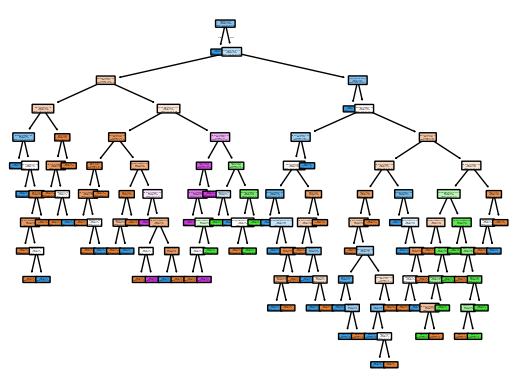

In [145]:
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["0", "1", "2", "3"],
    filled=True,
    rounded=True
)

plt.show()

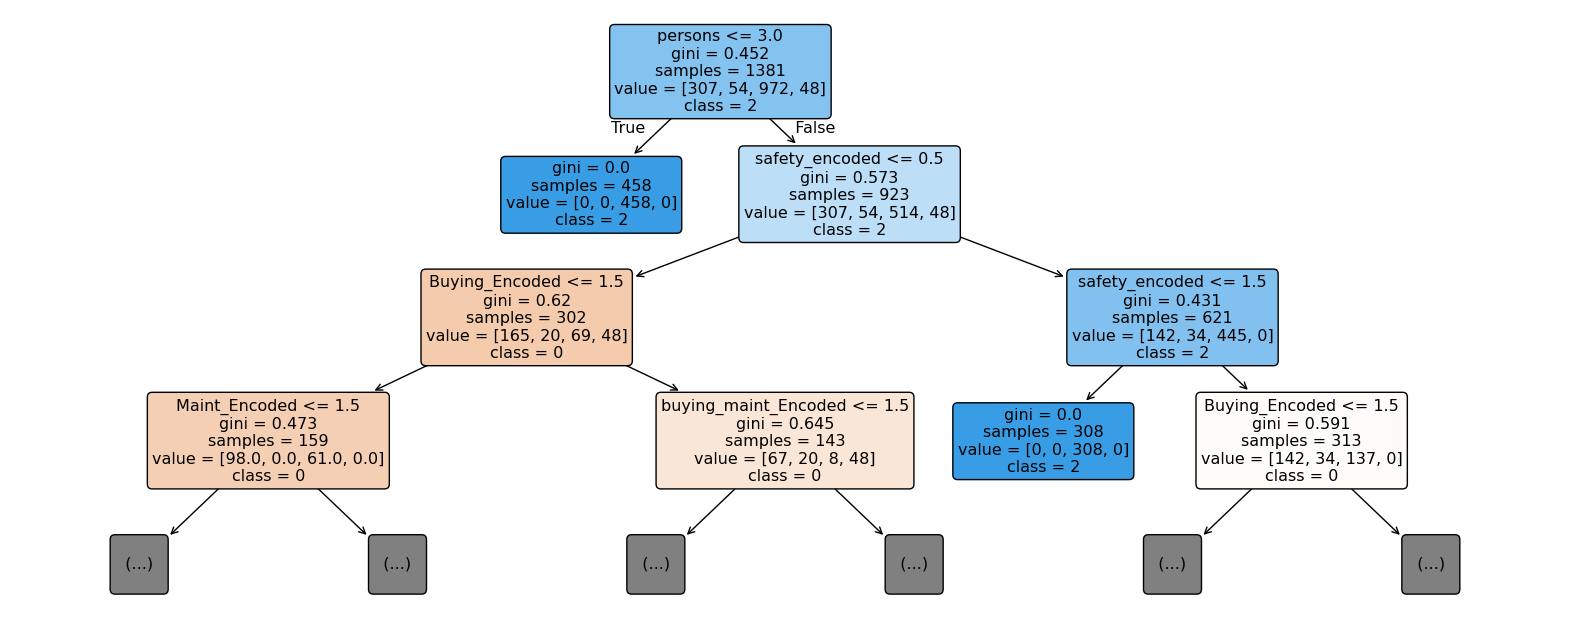

In [146]:
plt.figure(figsize=(20, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["0", "1", "2", "3"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.show()